# Systematic Failure Modes in Small Open-Weight LLMs
## A Controlled Study of Error Taxonomy and In-Context Learning Recovery
### COMP6242 — Deep Learning Group Project

**Abstract:** Large language models fail in consistent, characterisable ways — arithmetic slips,
distractor capture, premise-order sensitivity, hallucinated premises, and logical reversals.
This notebook runs a controlled empirical study coding failure traces into a 7-class taxonomy
and measuring per-error-class recovery across 7 ICL strategies (including a novel
**error-targeted ICL** condition) on open-weight models from Llama-3.2, Qwen2.5, Phi-3.5,
and Gemma-2 at 1–2B, 3B, and 7–9B parameter tiers.

**Primary output:** A reproducible per-error-class × per-ICL-strategy recovery heatmap.

---
**Workflow:**
1. Setup & mount Drive
2. Load datasets (GSM8K family / BBH / FOLIO)
3. Run baseline (S0 zero-shot) + error coding
4. Run ICL strategies S1–S6
5. Compute metrics & generate figures

**Checkpointing:** Results save to Drive every N items. Re-run cells to resume.


## 0. Environment Setup

In [1]:
# Install dependencies (run once per Colab session)
import subprocess, sys

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

pip_install([
    "transformers>=4.44.0",
    "datasets>=2.20.0",
    "accelerate>=0.30.0",
    "bitsandbytes>=0.43.0",
    "sentencepiece",
    "protobuf",
    "scipy",
    "scikit-learn",
    "pandas",
    "seaborn",
    "tqdm",
    "einops",
    "peft",
])
print("✓ Dependencies installed")


✓ Dependencies installed


## 1. Mount Google Drive & Clone GitHub Repo

In [2]:
from google.colab import drive, userdata
import os, sys

# Mount Drive
drive.mount('/content/drive', force_remount=False)

# ─── EDIT THIS ────────────────────────────────────────────────────────────────
GITHUB_REPO   = "https://github.com/Adithya-Rama/llm-failure-modes.git"  # <-- your repo
DRIVE_ROOT    = "/content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes"
HF_TOKEN      = userdata.get('HF_TOKEN')   # Set in Colab Secrets (key icon in sidebar)
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/checkpoints", exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/results", exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/figures", exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/hf_cache", exist_ok=True)

# Clone / update repo
REPO_DIR = "/content/llm-failure-modes"
if not os.path.exists(REPO_DIR):
    os.system(f"git clone {GITHUB_REPO} {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")

# Add src to path
if f"{REPO_DIR}" not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"✓ Drive mounted: {DRIVE_ROOT}")
print(f"✓ Repo at: {REPO_DIR}")


Mounted at /content/drive
✓ Drive mounted: /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes
✓ Repo at: /content/llm-failure-modes


## 2. Configuration & Imports

In [3]:
import os
os.environ["DRIVE_ROOT"] = DRIVE_ROOT
os.environ["HF_TOKEN"]   = HF_TOKEN or ""
os.environ["TRANSFORMERS_CACHE"] = f"{DRIVE_ROOT}/hf_cache"

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(f"{DRIVE_ROOT}/experiment.log"),
    ]
)

from src.config import (
    MODELS, DATASETS, ERROR_CLASSES, ICL_STRATEGIES, RUN_CONFIG,
    CHECKPOINT_DIR, RESULTS_DIR, FIGURES_DIR, CACHE_DIR
)
from src.data_loader import load_all_datasets, get_dataset_stats
from src.models import load_model, unload_model
from src.inference import run_experiment, run_all_strategies
from src.taxonomy import code_batch, build_error_class_map, sample_for_annotation, export_annotation_csv
from src.metrics import full_metrics_report, save_metrics
from src.visualize import (
    plot_recovery_heatmap, plot_family_comparison,
    plot_scaling_curves, plot_error_distribution,
    plot_robustness_ratios, plot_js_divergence, print_summary_table
)
from src.checkpointing import (
    load_all_checkpoints, print_checkpoint_status,
    export_full_results, get_checkpoint_path
)

print("✓ All imports successful")


✓ All imports successful


## 3. Run Configuration
Edit this cell to control what runs. Start small, scale up.

In [4]:
# -----------------------------------------------------------------------------
# EDIT THIS CELL to control the experiment scope
# Default profile is a tiny smoke test. Switch RUN_PROFILE to "main" only after
# rescoring old checkpoints and confirming parser sanity.
# -----------------------------------------------------------------------------

RUN_PROFILE = "smoke"  # "smoke" or "main"

# FULL_SCOPE_REFERENCE_DO_NOT_RUN_BY_DEFAULT
# Original ambitious grid retained for documentation/reporting only:
# FULL_SCOPE_MODELS = [
#     "qwen-3b", "llama-3b", "phi-3.5",
#     "qwen-7b", "llama-8b", "gemma-9b",
#     "qwen-1.5b", "llama-1b", "gemma-2b",
# ]
# FULL_SCOPE_DATASETS = [
#     "gsm8k", "gsm_symbolic", "gsm_plus", "gsm_ic",
#     "bbh_logical_deduction", "bbh_tracking", "folio",
# ]
# FULL_SCOPE_STRATEGIES = ["S0", "S1", "S2", "S3", "S4", "S5", "S6"]

HD_MODELS = [
    "qwen-3b",      # main no-auth baseline
    "phi-3.5",      # fixed-size family comparison
    "qwen-7b",      # scaling check
]

HD_DATASETS = [
    "gsm8k",         # clean arithmetic baseline
    "gsm_symbolic",  # perturbation robustness
    "gsm_ic",        # distractor capture
    "folio",         # formal/logical reasoning
]

HD_STRATEGIES = ["S0", "S1", "S3", "S5"]

OPTIONAL_ABLATION_MODEL = "qwen-3b"
OPTIONAL_ABLATION_DATASETS = ["gsm8k", "gsm_ic"]
OPTIONAL_ABLATION_STRATEGIES = ["S5_RANDOM", "S5_CORRECT_ONLY", "S6"]
OPTIONAL_ABLATION_SAMPLES = 50

if RUN_PROFILE == "smoke":
    ACTIVE_MODELS = ["qwen-3b"]
    ACTIVE_DATASETS = ["gsm8k", "gsm_ic", "folio"]
    ACTIVE_STRATEGIES = ["S0", "S1", "S5"]
    N_SAMPLES = 10
elif RUN_PROFILE == "main":
    ACTIVE_MODELS = HD_MODELS
    ACTIVE_DATASETS = HD_DATASETS
    ACTIVE_STRATEGIES = HD_STRATEGIES
    N_SAMPLES = 100
else:
    raise ValueError("RUN_PROFILE must be 'smoke' or 'main'")

# Checkpoint frequency
CHECKPOINT_EVERY = 50

# Random seed
SEED = 42

# Use 4-bit quantisation (recommended for 7-9B on Colab)
USE_QUANT = True

print("Run profile:      ", RUN_PROFILE)
print("Active models:    ", ACTIVE_MODELS)
print("Active datasets:  ", ACTIVE_DATASETS)
print("Active strategies:", ACTIVE_STRATEGIES)
print("N samples:        ", N_SAMPLES)
print("Optional ablation:", OPTIONAL_ABLATION_MODEL, OPTIONAL_ABLATION_DATASETS, OPTIONAL_ABLATION_STRATEGIES)


Run profile:       smoke
Active models:     ['qwen-3b']
Active datasets:   ['gsm8k', 'gsm_ic', 'folio']
Active strategies: ['S0', 'S1', 'S5']
N samples:         10
Optional ablation: qwen-3b ['gsm8k', 'gsm_ic'] ['S5_RANDOM', 'S5_CORRECT_ONLY', 'S6']


## 4. Load Datasets

In [5]:
from src.data_loader import load_dataset_by_key

datasets = {}
failed_datasets = []

for dk in ACTIVE_DATASETS:
    try:
        records = load_dataset_by_key(
            dk,
            n_samples=N_SAMPLES,
            seed=SEED,
            cache_dir=CACHE_DIR,
        )
        if records:
            datasets[dk] = records
            print(f"  ✓ {dk}: {len(records)} items")
        else:
            print(f"  ✗ {dk}: 0 items returned")
            failed_datasets.append(dk)
    except Exception as e:
        print(f"  ✗ {dk}: FAILED ({e})")
        failed_datasets.append(dk)

# Use only successfully loaded datasets
ACTIVE_DATASETS_LOADED = [dk for dk in ACTIVE_DATASETS if dk in datasets]
print(f"\n✓ Loaded {len(datasets)}/{len(ACTIVE_DATASETS)} datasets")
if failed_datasets:
    print(f"  Failed: {failed_datasets}")


README.md: 0.00B [00:00, ?B/s]

  ✓ gsm8k: 10 items
  ✓ gsm_ic: 10 items


README.md:   0%|          | 0.00/869 [00:00<?, ?B/s]

  ✓ folio: 10 items

✓ Loaded 3/3 datasets


In [6]:
# Preview samples from each dataset
for dk, records in datasets.items():
    cfg = DATASETS[dk]
    print(f"\n{'='*60}")
    print(f"Dataset: {dk} | Tier: {cfg['tier']} | N: {len(records)}")
    print(f"  Q: {records[0]['question'][:150]}...")
    print(f"  A: {records[0]['gold_answer']}")



Dataset: gsm8k | Tier: easy | N: 10
  Q: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now....
  A: 109

Dataset: gsm_ic | Tier: easy | N: 10
  Q: Maddy was given 40 chocolate eggs for Easter. She likes to eat two each day after school. If Maddy has two chocolate eggs after school each day, how m...
  A: 4

Dataset: folio | Tier: hard | N: 10
  Q: Premises:
All hydrocarbons are organic compounds .
All alkanes are hydrocarbons
All organic compounds are chemical compounds.
All organic compounds co...
  A: False


## 5. Check Existing Checkpoints
This shows what's already been computed. Runs resume automatically.

In [7]:
print_checkpoint_status(
    CHECKPOINT_DIR,
    ACTIVE_MODELS,
    ACTIVE_STRATEGIES,
    ACTIVE_DATASETS_LOADED,
)


Model                Strategy gsm8k           gsm_ic          folio          
-----------------------------------------------------------------------------
qwen-3b              S0       250             150             0              
qwen-3b              S1       0               0               0              
qwen-3b              S5       0               0               0              


## 5.1 Rescore Existing Checkpoints

Run this after parser changes so expensive generations already saved in Drive are reused instead of rerun.


In [8]:
from src.checkpointing import rescore_all_checkpoints

# Rescore all checkpoints for the active model/dataset set.
# This fixes old runs where intermediate equation values were mistaken for final answers.
rescore_summaries = rescore_all_checkpoints(
    CHECKPOINT_DIR,
    model_keys=ACTIVE_MODELS,
    strategy_keys=None,  # include any already-run strategy for these models/datasets
    dataset_keys=ACTIVE_DATASETS_LOADED,
    recode_errors=True,
    save=True,
)

if not rescore_summaries:
    print("No matching checkpoints found to rescore.")
else:
    for s in rescore_summaries:
        print(
            f"{s['path']}: n={s['n']} changed={s['changed']} "
            f"acc {s['before_accuracy']:.3f} -> {s['after_accuracy']:.3f}"
        )


/content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/checkpoints/qwen-3b__S0__gsm8k.json: n=250 changed=227 acc 0.108 -> 0.848
/content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/checkpoints/qwen-3b__S0__gsm_ic.json: n=150 changed=145 acc 0.060 -> 0.793


## 6. Run Experiments

**Strategy:**
1. Run S0 (zero-shot baseline) first on ALL models — this provides error classes for S5.
2. Code errors from S0 results.
3. Run S1–S6 (including S5 with error-class-targeted exemplars).

> **Tip:** Run one model at a time. Each model takes ~30–90 min on Colab A100.
> Checkpoints save every N items, so disconnects are safe.


In [9]:
# ─────────────────────────────────────────────────────────────────
# PHASE 1: Baseline (S0 zero-shot) — run on all models first
# ─────────────────────────────────────────────────────────────────
from src.taxonomy import code_batch, build_error_class_map
from src.config import DATASETS as DATASET_CFGS

baseline_error_maps = {}   # {model_key → {dataset_key → {id → error_class}}}

for model_key in ACTIVE_MODELS:
    print(f"\n{'='*60}")
    print(f"MODEL: {model_key} | STRATEGY: S0 (baseline)")
    print(f"{'='*60}")

    # Check whether each S0 checkpoint covers the currently loaded records.
    # File existence alone is not enough: smoke checkpoints may contain only
    # 10 items while the main profile expects 100.
    from src.checkpointing import load_checkpoint
    all_done = all(
        {r["id"] for r in datasets[dk]}.issubset(
            {r["id"] for r in load_checkpoint(
                get_checkpoint_path(CHECKPOINT_DIR, model_key, "S0", dk)
            )[0]}
        )
        for dk in ACTIVE_DATASETS_LOADED
    )
    if all_done:
        print(f"  ✓ S0 checkpoints already cover active records, skipping inference")
    else:
        model, tokenizer, model_cfg = load_model(
            model_key,
            use_quantisation=USE_QUANT,
            hf_token=HF_TOKEN,
            cache_dir=CACHE_DIR,
        )

        run_all_strategies(
            model, tokenizer, model_cfg, model_key,
            datasets=datasets,
            strategy_keys=["S0"],
            checkpoint_dir=CHECKPOINT_DIR,
            checkpoint_every=CHECKPOINT_EVERY,
            seed=SEED,
        )
        unload_model(model, tokenizer)
        print(f"  ✓ S0 inference complete")

    # Load S0 results and code errors
    from src.checkpointing import load_checkpoint
    error_map_this_model = {}
    for dk in ACTIVE_DATASETS_LOADED:
        ckpt_path = get_checkpoint_path(CHECKPOINT_DIR, model_key, "S0", dk)
        results, _ = load_checkpoint(ckpt_path)
        answer_type = DATASET_CFGS[dk]["answer_type"]
        results = code_batch(results, answer_type)
        # Re-save with error codes
        from src.checkpointing import save_checkpoint
        save_checkpoint(ckpt_path, results)
        error_map_this_model[dk] = build_error_class_map(results)
        n_errors = sum(1 for r in results if not r["correct"])
        print(f"    {dk}: {len(results)} items, {n_errors} errors coded")

    baseline_error_maps[model_key] = error_map_this_model

print("\n✓ Phase 1 (S0 baseline + error coding) complete")



MODEL: qwen-3b | STRATEGY: S0 (baseline)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Qwen2.5-3B|S0|folio:   0%|          | 0/10 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Qwen2.5-3B|S0|folio: 100%|██████████| 10/10 [02:02<00:00, 12.29s/it]


  ✓ S0 inference complete
    gsm8k: 250 items, 38 errors coded
    gsm_ic: 150 items, 31 errors coded
    folio: 10 items, 5 errors coded

✓ Phase 1 (S0 baseline + error coding) complete


In [10]:
# ─────────────────────────────────────────────────────────────────
# PHASE 2: Active ICL strategies
# ─────────────────────────────────────────────────────────────────
ICL_ONLY = [s for s in ACTIVE_STRATEGIES if s != "S0"]

for model_key in ACTIVE_MODELS:
    print(f"\n{'='*60}")
    print(f"MODEL: {model_key} | STRATEGIES: {ICL_ONLY}")
    print(f"{'='*60}")

    # Build S5 error class map for this model
    s5_error_classes = baseline_error_maps.get(model_key, {})

    model, tokenizer, model_cfg = load_model(
        model_key,
        use_quantisation=USE_QUANT,
        hf_token=HF_TOKEN,
        cache_dir=CACHE_DIR,
    )

    run_all_strategies(
        model, tokenizer, model_cfg, model_key,
        datasets=datasets,
        strategy_keys=ICL_ONLY,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_every=CHECKPOINT_EVERY,
        baseline_errors=s5_error_classes,  # used by S5
        seed=SEED,
    )

    unload_model(model, tokenizer)
    print(f"  ✓ {model_key} complete")

print("\n✓ Phase 2 (active ICL strategies) complete")



MODEL: qwen-3b | STRATEGIES: ['S1', 'S5']


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Qwen2.5-3B|S1|gsm8k: 100%|██████████| 10/10 [02:47<00:00, 16.72s/it]
Qwen2.5-3B|S1|gsm_ic: 100%|██████████| 10/10 [02:34<00:00, 15.46s/it]
Qwen2.5-3B|S1|folio: 100%|██████████| 10/10 [03:12<00:00, 19.24s/it]
Qwen2.5-3B|S5|gsm8k: 100%|██████████| 10/10 [02:15<00:00, 13.59s/it]
Qwen2.5-3B|S5|gsm_ic: 100%|██████████| 10/10 [01:38<00:00,  9.86s/it]
Qwen2.5-3B|S5|folio: 100%|██████████| 10/10 [02:15<00:00, 13.56s/it]


  ✓ qwen-3b complete

✓ Phase 2 (active ICL strategies) complete


## 7. Inter-Annotator Agreement (Cohen's κ)
Export a sample CSV for human labelling, then compute κ after both annotators label it.

In [11]:
from src.checkpointing import load_checkpoint
from src.taxonomy import sample_for_annotation, export_annotation_csv, compute_kappa
from src.config import DATASETS as DATASET_CFGS

# Collect a sample of S0 failures across all models for annotation
all_s0_failures = []
for model_key in ACTIVE_MODELS[:3]:  # Use first 3 models for annotation sample
    for dk in ACTIVE_DATASETS_LOADED:
        ckpt = get_checkpoint_path(CHECKPOINT_DIR, model_key, "S0", dk)
        results, _ = load_checkpoint(ckpt)
        all_s0_failures.extend([r for r in results if not r.get("correct")])

sample = sample_for_annotation(all_s0_failures, n=150, seed=SEED)
annotation_csv = f"{RESULTS_DIR}/annotation_sample.csv"
export_annotation_csv(sample, annotation_csv)
print(f"✓ Annotation CSV exported to: {annotation_csv}")
print(f"  {len(sample)} items for human labelling")
print("  → Fill in the 'human_label' column and re-upload to Drive")

# ── After human labelling, load and compute kappa ──
# Uncomment and run this block after annotation is complete:
#
# import pandas as pd
# ann_df = pd.read_csv(annotation_csv)
# auto_labels = ann_df["auto_label"].tolist()
# human_labels = ann_df["human_label"].tolist()
# # Drop rows where human didn't annotate
# paired = [(a, h) for a, h in zip(auto_labels, human_labels) if pd.notna(h) and h.strip()]
# if paired:
#     auto, human = zip(*paired)
#     kappa = compute_kappa(list(auto), list(human))
#     print(f"\nCohen's κ = {kappa:.3f}")
#     if kappa >= 0.8: print("  → Excellent agreement")
#     elif kappa >= 0.6: print("  → Substantial agreement")
#     else: print("  → Moderate agreement — review taxonomy")


✓ Annotation CSV exported to: /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/results/annotation_sample.csv
  74 items for human labelling
  → Fill in the 'human_label' column and re-upload to Drive


## 8. Compute All Metrics

In [12]:
from src.checkpointing import load_all_checkpoints, filter_all_results_to_records
from src.metrics import full_metrics_report, save_metrics

# Load all completed results from checkpoints
print("Loading all results from checkpoints...")
all_results = load_all_checkpoints(CHECKPOINT_DIR)

# Restrict analysis to the currently loaded N_SAMPLES subset when old checkpoints are larger.
all_results = filter_all_results_to_records(all_results, datasets)

# Quick status
total = sum(
    len(v)
    for m in all_results.values()
    for s in m.values()
    for v in s.values()
)
print(f"✓ {total} total results loaded")

# Compute metrics
metrics = full_metrics_report(
    all_results,
    model_keys=ACTIVE_MODELS,
    strategy_keys=ACTIVE_STRATEGIES,
    dataset_keys=ACTIVE_DATASETS_LOADED,
    model_configs=MODELS,
)

save_metrics(metrics, RESULTS_DIR)
print("✓ Metrics computed and saved")


Loading all results from checkpoints...


✓ 390 total results loaded
✓ Metrics computed and saved


In [13]:
# Print summary tables
from src.visualize import print_summary_table
print_summary_table(metrics["accuracy"], ACTIVE_STRATEGIES)

# Show recovery delta
print("\n=== Recovery Delta (per error class × strategy) ===")
print(metrics["recovery"].round(3).to_string())



=== Mean Accuracy per Model (averaged over datasets) ===
              S0    S1    S5
model_name                  
Qwen2.5-3B 0.667 0.500 0.567

=== Mean Accuracy per Strategy (averaged over models) ===
S0   0.667
S1   0.500
S5   0.567

=== Recovery Delta (per error class × strategy) ===
              S1   S5
error_class          
E1           0.0  1.0
E2           0.0  0.0
E3           0.0  0.0
E4           NaN  NaN
E5           NaN  NaN
E6           0.0  0.0
E7           NaN  NaN


## 9. Generate All Figures

Generating Fig 1: Recovery Heatmap...


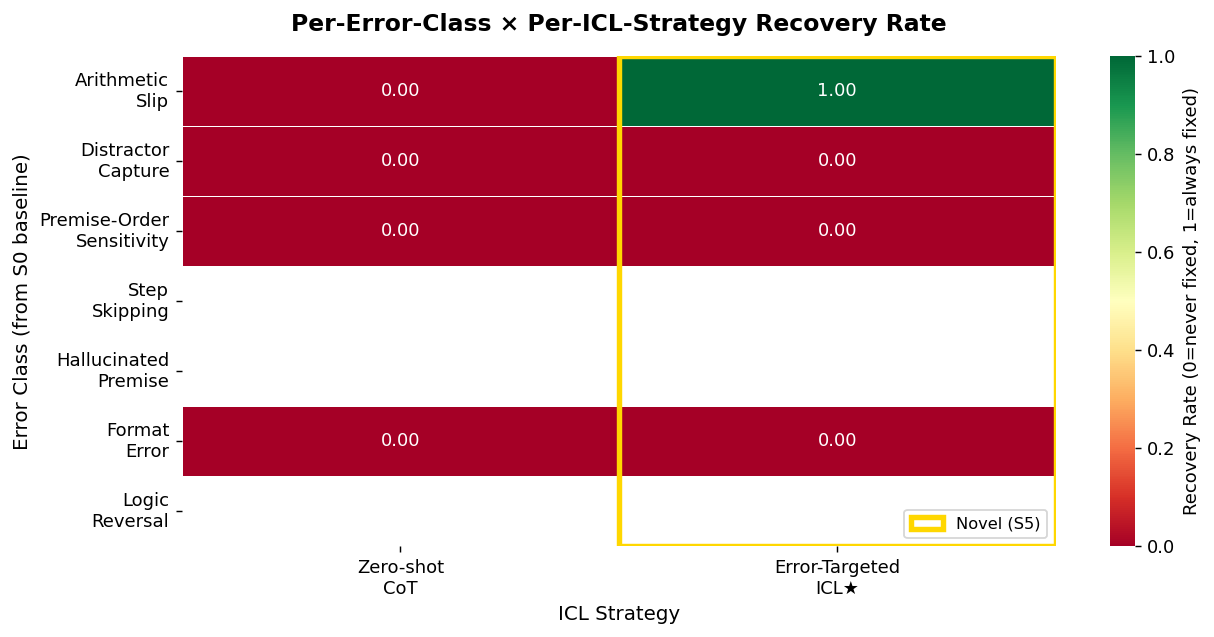

Generating Fig 2: Family Comparison...


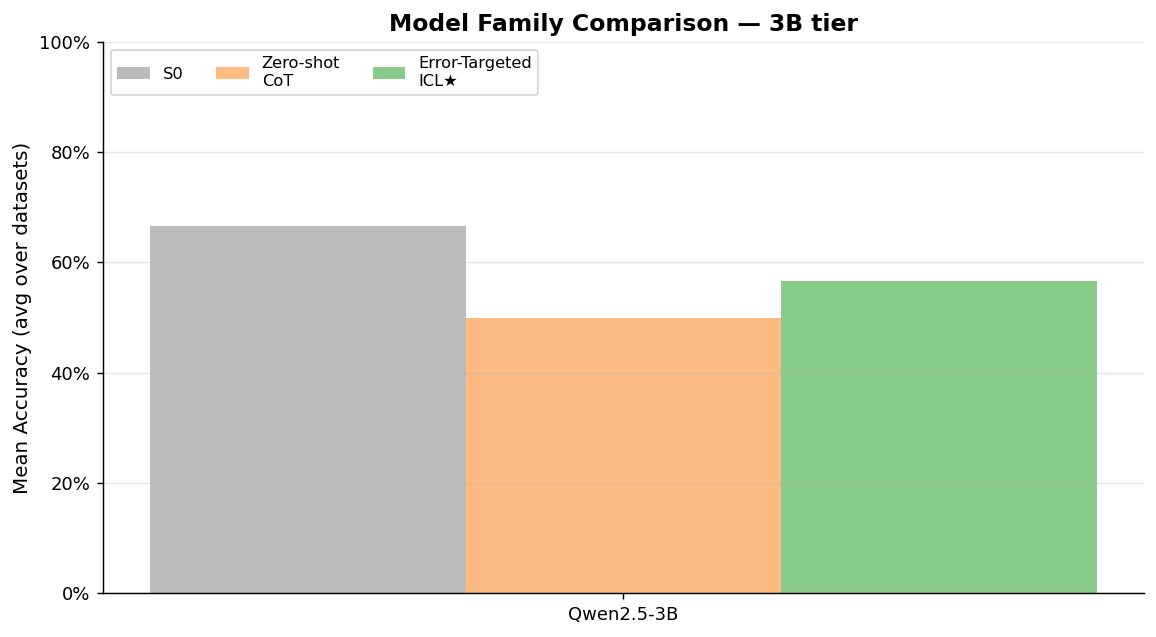

Generating Fig 3: Scaling Curves...


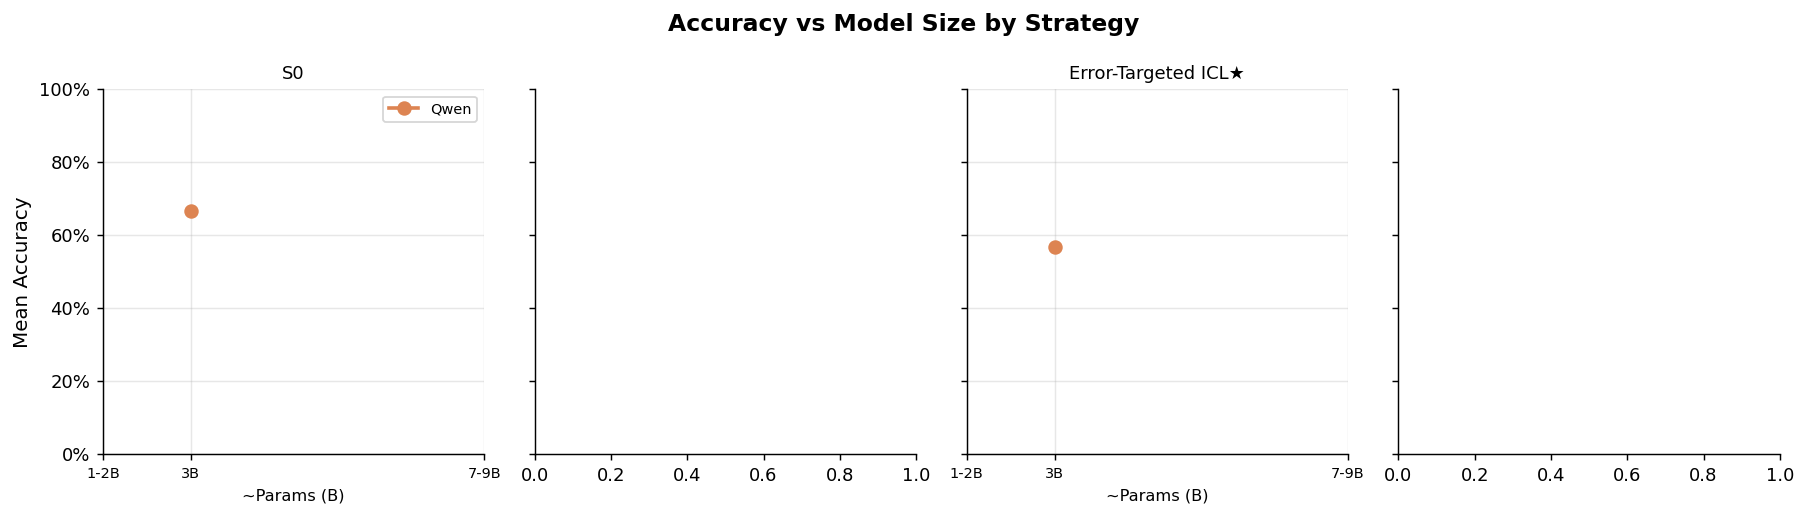

Generating Fig 4: Error Distribution...


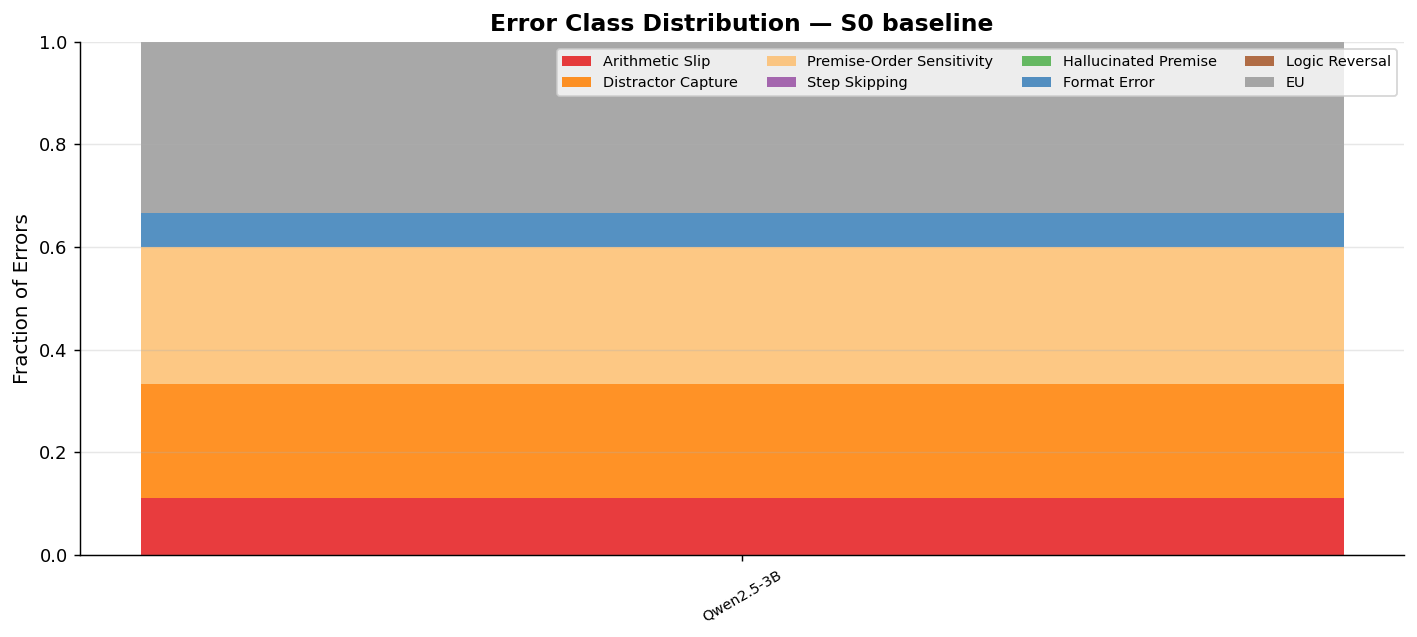

Generating Fig 5: Robustness Ratios...


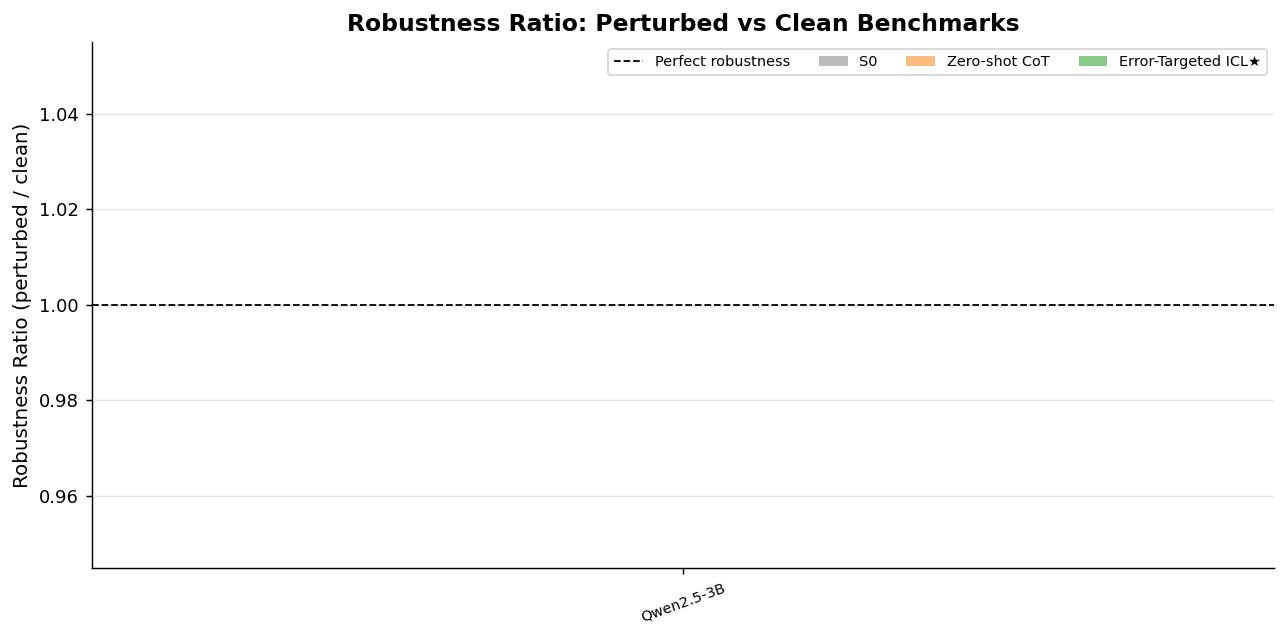

Generating Fig 6: JS Divergence...


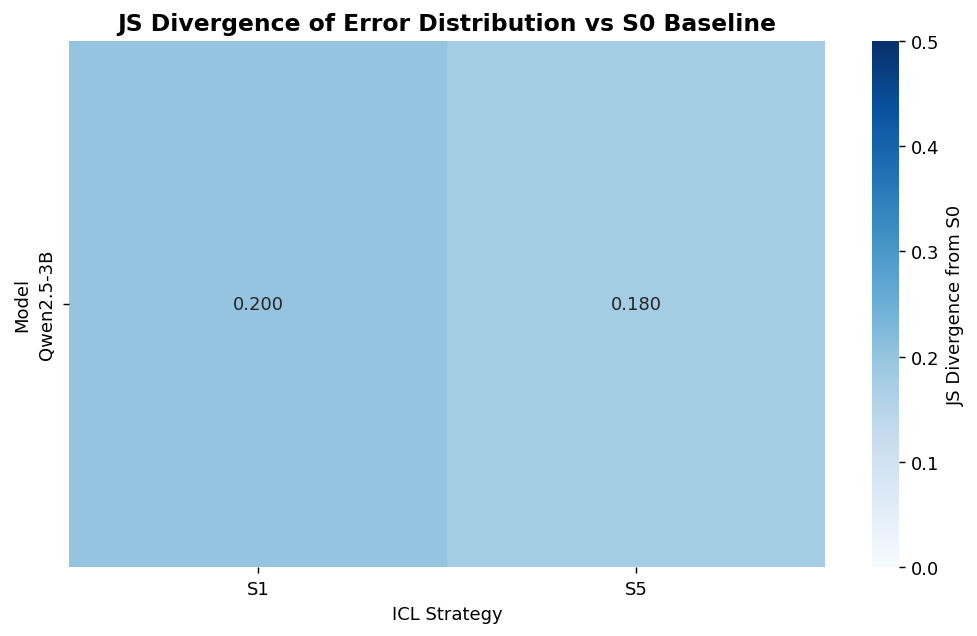


✓ All figures saved to /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/figures


In [14]:
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Fig 1: Main recovery heatmap (the paper's key figure)
print("Generating Fig 1: Recovery Heatmap...")
plot_recovery_heatmap(metrics["recovery"], figures_dir=FIGURES_DIR)

# Fig 2: Family comparison at 3B tier
print("Generating Fig 2: Family Comparison...")
plot_family_comparison(
    metrics["accuracy"],
    size_tier="3B",
    strategy_keys=["S0", "S1", "S3", "S5", "S6"],
    figures_dir=FIGURES_DIR,
)

# Fig 3: Scaling curves
print("Generating Fig 3: Scaling Curves...")
plot_scaling_curves(metrics["accuracy"], figures_dir=FIGURES_DIR)

# Fig 4: Error distribution at baseline
print("Generating Fig 4: Error Distribution...")
plot_error_distribution(metrics["error_dist"], strategy="S0", figures_dir=FIGURES_DIR)

# Fig 5: Robustness ratios
print("Generating Fig 5: Robustness Ratios...")
plot_robustness_ratios(metrics["robustness"], figures_dir=FIGURES_DIR)

# Fig 6: JS divergence
print("Generating Fig 6: JS Divergence...")
plot_js_divergence(
    all_results, ACTIVE_MODELS, ACTIVE_STRATEGIES,
    ACTIVE_DATASETS_LOADED, MODELS, figures_dir=FIGURES_DIR,
)

print(f"\n✓ All figures saved to {FIGURES_DIR}")


## 10. Export Full Results & Archive

In [15]:
from src.checkpointing import export_full_results
import json, time

timestamp = time.strftime("%Y%m%d_%H%M")
archive_path = f"{RESULTS_DIR}/all_results_{timestamp}.json"
export_full_results(all_results, archive_path)
print(f"✓ Full results archived to {archive_path}")

# Export metrics as CSV
metrics["accuracy"].to_csv(f"{RESULTS_DIR}/accuracy_{timestamp}.csv")
metrics["recovery"].to_csv(f"{RESULTS_DIR}/recovery_heatmap_{timestamp}.csv")
print("✓ CSVs exported")

# Summary
print(f"\n{'='*60}")
print("EXPERIMENT COMPLETE")
print(f"{'='*60}")
print(f"Figures dir:  {FIGURES_DIR}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Checkpoints:  {CHECKPOINT_DIR}")
print(f"Archive:      {archive_path}")


✓ Full results archived to /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/results/all_results_20260510_0818.json
✓ CSVs exported

EXPERIMENT COMPLETE
Figures dir:  /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/figures
Results dir:  /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/results
Checkpoints:  /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/checkpoints
Archive:      /content/drive/MyDrive/COMP6242 - Deep Learning/Project/llm-failure-modes/results/all_results_20260510_0818.json


## 11. Optional Ablations: Targeting and Self-Consistency

Run after the main qwen-3b S0 baseline exists. This keeps the HD novelty claims honest without expanding the full grid.


In [16]:
# Optional ablations: S5 random target, S5 correct-only, and S6 on a 50-item subset
from src.inference import run_all_strategies
from src.taxonomy import build_error_class_map, code_batch
from src.checkpointing import load_checkpoint
from src.config import DATASETS as DATASET_CFGS

ABLATION_MODEL = OPTIONAL_ABLATION_MODEL
ABLATION_DATASETS = [dk for dk in OPTIONAL_ABLATION_DATASETS if dk in datasets]
ABLATION_STRATEGIES = OPTIONAL_ABLATION_STRATEGIES
ABLATION_N = OPTIONAL_ABLATION_SAMPLES

ablation_datasets = {
    dk: datasets[dk][:min(ABLATION_N, len(datasets[dk]))]
    for dk in ABLATION_DATASETS
}

# Build baseline error maps from existing S0 checkpoints.
ablation_error_maps = {}
for dk in ABLATION_DATASETS:
    ckpt = get_checkpoint_path(CHECKPOINT_DIR, ABLATION_MODEL, "S0", dk)
    results, _ = load_checkpoint(ckpt)
    if not results:
        raise RuntimeError(f"Missing S0 checkpoint for {ABLATION_MODEL}/{dk}; run Phase 1 first.")
    answer_type = DATASET_CFGS[dk]["answer_type"]
    code_batch(results, answer_type)
    ablation_error_maps[dk] = build_error_class_map(results)

model, tokenizer, model_cfg = load_model(
    ABLATION_MODEL,
    use_quantisation=USE_QUANT,
    hf_token=HF_TOKEN,
    cache_dir=CACHE_DIR,
)

run_all_strategies(
    model, tokenizer, model_cfg, ABLATION_MODEL,
    datasets=ablation_datasets,
    strategy_keys=ABLATION_STRATEGIES,
    checkpoint_dir=CHECKPOINT_DIR,
    checkpoint_every=CHECKPOINT_EVERY,
    baseline_errors=ablation_error_maps,
    seed=SEED,
)

unload_model(model, tokenizer)
print("✓ Optional ablations complete")


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Qwen2.5-3B|S5_RANDOM|gsm8k: 100%|██████████| 10/10 [02:45<00:00, 16.58s/it]
Qwen2.5-3B|S5_RANDOM|gsm_ic: 100%|██████████| 10/10 [01:46<00:00, 10.68s/it]
Qwen2.5-3B|S5_CORRECT_ONLY|gsm8k: 100%|██████████| 10/10 [02:16<00:00, 13.64s/it]
Qwen2.5-3B|S5_CORRECT_ONLY|gsm_ic: 100%|██████████| 10/10 [01:41<00:00, 10.17s/it]
Qwen2.5-3B|S6|gsm8k: 100%|██████████| 10/10 [14:25<00:00, 86.60s/it]
Qwen2.5-3B|S6|gsm_ic: 100%|██████████| 10/10 [13:00<00:00, 78.08s/it]


✓ Optional ablations complete


## 12. Statistical Significance (McNemar's Test)

In [17]:
from src.metrics import mcnemar_test
from src.checkpointing import load_checkpoint

# Compare S0 vs S5 (novel strategy) for statistical significance
# Run on first model, first dataset with enough items

MODEL_FOR_TEST = "qwen-3b"
DATASET_FOR_TEST = "gsm8k"

s0_ckpt = get_checkpoint_path(CHECKPOINT_DIR, MODEL_FOR_TEST, "S0", DATASET_FOR_TEST)
s5_ckpt = get_checkpoint_path(CHECKPOINT_DIR, MODEL_FOR_TEST, "S5", DATASET_FOR_TEST)

s0_results, _ = load_checkpoint(s0_ckpt)
s5_results, _ = load_checkpoint(s5_ckpt)

if s0_results and s5_results:
    # Align by record ID
    s0_by_id = {r["id"]: r for r in s0_results}
    s5_by_id = {r["id"]: r for r in s5_results}
    common_ids = sorted(set(s0_by_id) & set(s5_by_id))

    s0_aligned = [s0_by_id[i] for i in common_ids]
    s5_aligned = [s5_by_id[i] for i in common_ids]

    chi2, p = mcnemar_test(s0_aligned, s5_aligned)
    print(f"McNemar's Test: S0 vs S5 on {MODEL_FOR_TEST} / {DATASET_FOR_TEST}")
    print(f"  χ² = {chi2:.3f}, p = {p:.4f}")
    print(f"  {'Significant (p < 0.05)' if p < 0.05 else 'Not significant (p >= 0.05)'}")
else:
    print("Checkpoints not found — run experiments first.")


McNemar's Test: S0 vs S5 on qwen-3b / gsm8k
  χ² = 0.500, p = 0.4795
  Not significant (p >= 0.05)
